# MACHINE LEARNING - Clustering Project
**Etudiants** : Louis-Gabriel BROSSIER | Victor LOUX | Hoang-Triet NGUYEN

## Introduction
L'hiver approche, les soirées s'allongent, et notre backlog Steam ne va clairement pas se trier tout seul. On a donc besoin d'analyser un dataset de jeux et d'utiliser du clustering pour repérer les pépites parfaites pour hiberner intelligemment.

### Notre jeu de données
*   C'est quoi le dataset ?

Ce dataset a été créé en récupérant des données sur Steam et sur Steam Games Scraper, qui collecte des données à l'aide de l'API Steam et Steam Spy. Elle est à jour jusqu'à mars 2025. Ce dataset nous permet d'avoir une vue globale sur un grand nombre de features pour chacun des jeux du Steam Store.

*   Lister tous les features

 Voici toutes les features que nous avons selectionnés : -appid -name - release_date -required_age -price - dlc_count -metacritic_score -achievements -recommendations -categories -positive -negative -median_playtime_forever -peak_ccu -pct_pos_total

### Notre objectives


## Importation des librairies et du dataset

In [30]:
# Importation des librairies
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("./dataset/Steam_Games_2025.csv")


## Prétraitement des données


In [31]:
## Supprimer 'appid' du dataset
if ('appid' in df.columns):
    df = df.drop(columns=['appid'])

## Supprimer les jeux sans recommandations
df = df[df['metacritic_score'] > 0]
## Garder que 500 jeux avec le plus de recommandations
df = df.nlargest(3000, 'metacritic_score')

## Supprimer 'positif' et 'negative' car redondant avec 'pct_pos_total'
df = df.drop(columns=['positive', 'negative'])

## Transformer 'release_date' en Année de sortie et changer le nom de la colonne
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
df = df.rename(columns={'release_date': 'release_year'})

## Extraire 'single_player' et 'multi_player' de la colonne 'categories'
def extract_category(df: pd.DataFrame, categories_name: str) -> int:
    return 1 if categories_name and df.find(categories_name) != -1 else 0
df['single_player'] = df['categories'].apply(extract_category, args=('Single-player',))
df['multi_player'] = df['categories'].apply(extract_category, args=('Multi-player',))
df = df.drop(columns=['categories'])

# Verifier les modifications
# Nombre d'échantillons et de features
print("Number of samples:", df.shape[0])
print("Number of features:", df.shape[1])
df.head(10)

Number of samples: 3000
Number of features: 14


,name,release_year,required_age,price,dlc_count,metacritic_score,achievements,recommendations,median_playtime_forever,peak_ccu,pct_pos_total,num_reviews_total,single_player,multi_player
171,Disco Elysium - The Final Cut,2019,0,39.99,2,97,45,98796,459,1727,93,98950,1,0
3,Grand Theft Auto V Legacy,2015,17,0.00,0,96,77,1803063,7101,117698,87,1803832,1,1
16,Baldur's Gate 3,2023,17,59.99,2,96,54,647659,5712,48021,96,648637,1,1
12,ELDEN RING,2022,16,59.99,2,94,42,749109,5675,46121,92,749606,1,1
89,The Elder Scrolls V: Skyrim,2011,17,19.99,1,94,75,181083,0,2380,94,181095,1,0
160,BioShock Infinite,2013,17,29.99,5,94,80,104602,612,320,93,104626,1,0
724,Divinity: Original Sin - Enhanced Edition,2015,0,39.99,1,94,54,23450,393,1106,89,23474,1,1
3074,Cobalt Core,2023,0,19.99,1,94,15,3153,524,106,96,3155,1,0
14851,Mass Effect 2 (2010) Edition,2023,17,29.99,0,94,0,190,0,18,73,190,1,0
11,The Witcher 3: Wild Hunt,2015,17,39.99,22,93,78,761658,927,15129,96,751939,1,0


## Exploration des données

In [32]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

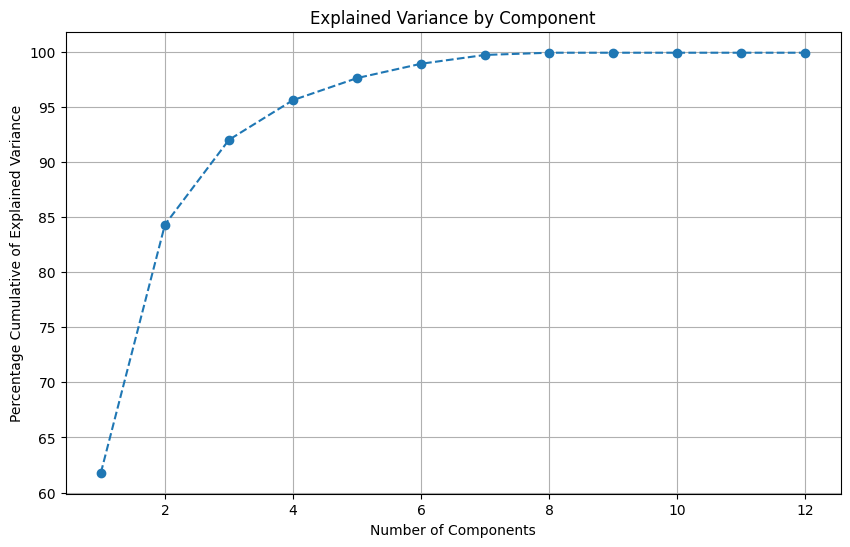

In [33]:
from sklearn.preprocessing import Normalizer

data = df.drop(columns=['name', 'release_year'])

df_normalized = Normalizer().fit_transform(data.values)
# print(df_normalized.shape)
# print(df_normalized)
pca = PCA()
pca.fit(df_normalized)
per_var = np.round(pca.explained_variance_ratio_*100, decimals = 1)

plt.figure(figsize = (10,6))
plt.plot(range(1, len(per_var)+1), per_var.cumsum(), marker = "o", linestyle = "--")
plt.grid()
plt.ylabel("Percentage Cumulative of Explained Variance")
plt.xlabel("Number of Components")
plt.title("Explained Variance by Component")
plt.show()

In [34]:
# TSNE
from sklearn.manifold import TSNE

#data2 = data.drop(columns=['price'])
df_normalized2 = Normalizer().fit_transform(data.values)


tsne2D = TSNE(n_components=2,perplexity=15, init='pca', random_state=0)
data2D_tsne = tsne2D.fit_transform(df_normalized2)
tsne2D.kl_divergence_

tsne3D = TSNE(n_components=3,perplexity=15, init='pca', random_state=0)
data3D_tsne = tsne3D.fit_transform(df_normalized2)
tsne3D.kl_divergence_

0.6840730905532837

In [35]:
import plotly.express as px

log_price = np.log10(df['recommendations'])

fig = px.scatter(
    x=data2D_tsne[:, 0],
    y=data2D_tsne[:, 1],
    color=log_price,
    title="t-SNE visualization of Custom Classification dataset",
    labels={
        "x": "First t-SNE",
        "y": "Second t-SNE",
        "color": "log(Recommendations)"
    }
)

fig.show()

fig = px.scatter_3d(
    x=data3D_tsne[:, 0],
    y=data3D_tsne[:, 1],
    z=data3D_tsne[:, 2],
    color=log_price,
    title="t-SNE visualization of Custom Classification dataset",
    labels={"color": "log(Recommendations)"},
    opacity=0.7
)

fig.update_layout(
    scene=dict(
        xaxis_title="First t-SNE",
        yaxis_title="Second t-SNE",
        zaxis_title="Third t-SNE"
    )
)

fig.show()


c:\Users\samsung\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

divide by zero encountered in log10



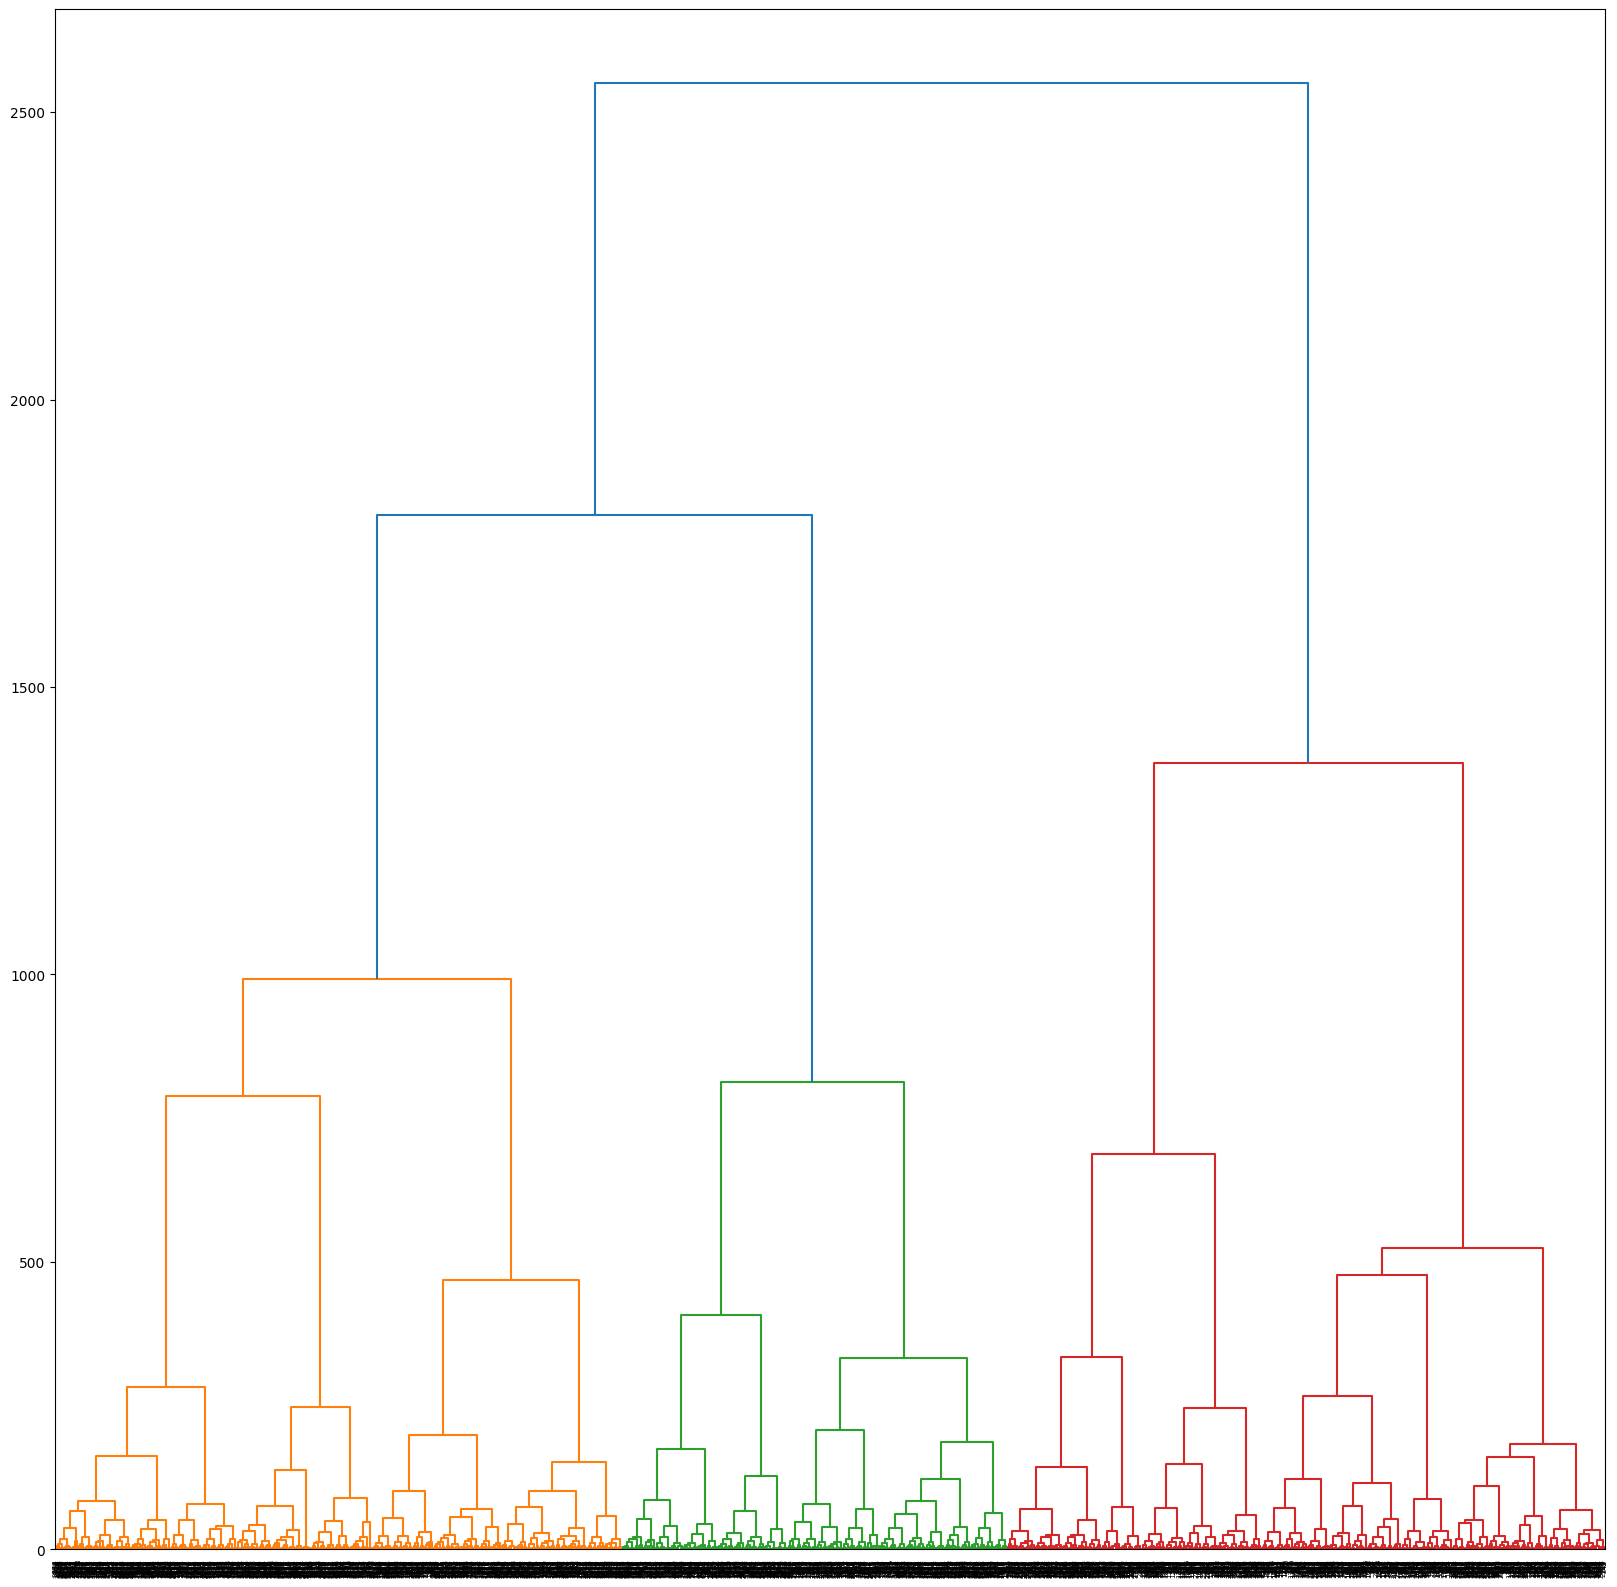

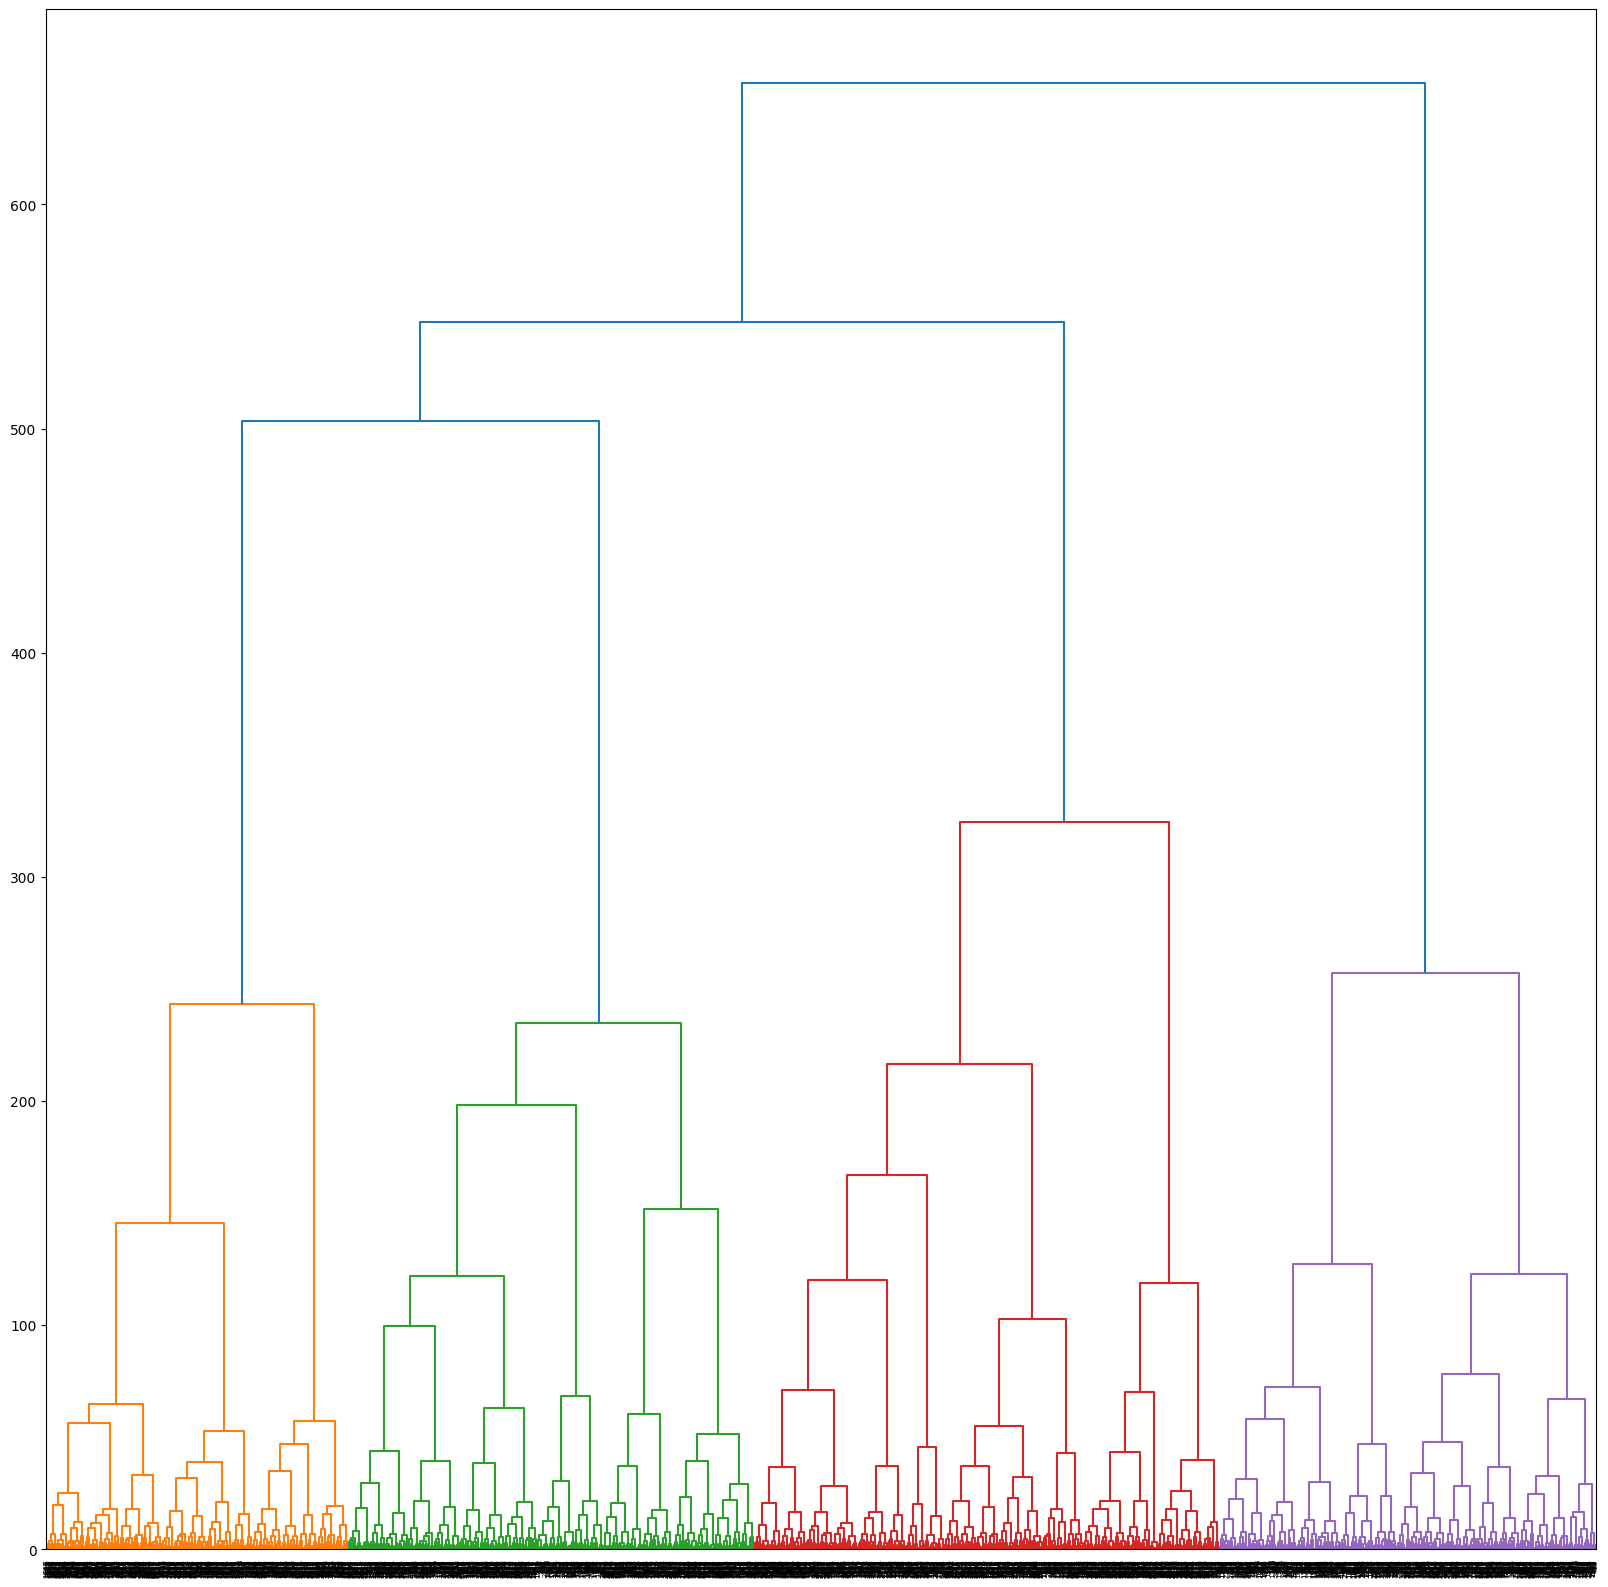

In [48]:
import scipy.cluster.hierarchy as shc



linked_mat1 = shc.linkage(data2D_tsne, "ward")

plt.figure(figsize=(20,20))
shc.dendrogram(linked_mat1,
              orientation='top',
              distance_sort='descending',
              show_leaf_counts=True)
plt.show()

linked_mat2 = shc.linkage(data3D_tsne, "ward")

plt.figure(figsize=(20,20))
shc.dendrogram(linked_mat2,
              orientation='top',
              distance_sort='descending',
              show_leaf_counts=True)
plt.show()



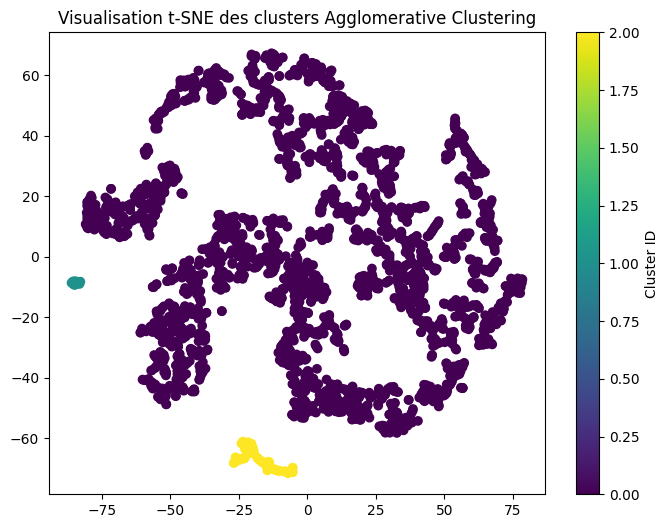

In [61]:
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

clusters = AgglomerativeClustering(n_clusters=None,distance_threshold=8, linkage='single').fit(data2D_tsne)

clusters2 = AgglomerativeClustering(n_clusters=None,distance_threshold=3, linkage='single').fit(data3D_tsne)



# Ensuite visualiser
plt.figure(figsize=(8, 6))
plt.scatter(data2D_tsne[:, 0], data2D_tsne[:, 1], c=clusters.labels_, cmap='viridis')
plt.colorbar(label='Cluster ID')
plt.title('Visualisation t-SNE des clusters Agglomerative Clustering')
plt.show()

fig = px.scatter_3d(
    x=data3D_tsne[:, 0],
    y=data3D_tsne[:, 1],
    z=data3D_tsne[:, 2],
    color=clusters2.labels_,

    title="t-SNE visualization of Custom Classification dataset",
    labels={"color": "cluster_ID"},
    opacity=0.7
)

fig.update_layout(
    scene=dict(
        xaxis_title="First t-SNE",
        yaxis_title="Second t-SNE",
        zaxis_title="Third t-SNE"
    )
)

fig.show()



In [ ]:

results = pd.DataFrame({
    'Nom': df['name'],
    'prix': df['price'],
    'reco': df['recommendations'],
    'Cluster': clusters
})



# 3. Afficher les premières lignes
results.head(100)

,Nom,prix,reco,Cluster
171,Disco Elysium - The Final Cut,39.99,98796,0
3,Grand Theft Auto V Legacy,0.00,1803063,0
16,Baldur's Gate 3,59.99,647659,0
12,ELDEN RING,59.99,749109,0
89,The Elder Scrolls V: Skyrim,19.99,181083,0
...,...,...,...,...
1065,Neon White,24.99,14270,0
1088,Fallout: A Post Nuclear Role Playing Game,9.99,14036,0
1135,Nuclear Throne,11.99,13412,0
1217,Rise of Nations: Extended Edition,19.99,12160,0
